In [1]:
import pandas as pd
import numpy as np

# --- 1. CARREGAMENTO DOS DADOS TRATADOS ---

# Nomes dos arquivos que foram salvos anteriormente
pib_path = 'pib_tratado.pkl'
desemprego_path = 'desemprego_tratado.pkl'

try:
    # Carregar os DataFrames a partir dos arquivos .pkl
    df_pib = pd.read_pickle(pib_path)
    df_desemprego = pd.read_pickle(desemprego_path)

    print("--- Dados do PIB carregados (head) ---")
    print(df_pib.head())
    print("\n" + "="*50 + "\n")
    
    print("--- Dados de Desemprego carregados (head) ---")
    print(df_desemprego.head())
    print("\n" + "="*50 + "\n")

except FileNotFoundError as e:
    print(f"Erro: Arquivo não encontrado. Verifique se os arquivos '{pib_path}' e '{desemprego_path}' estão no mesmo diretório que este notebook.")
    print(f"Detalhe do erro: {e}")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao carregar os dados: {e}")


# --- 2. UNIFICAÇÃO DOS DADOS ---

# Juntar os dois DataFrames pelo índice (que é a data)
# 'inner' join garante que teremos apenas as datas para as quais ambos os dados existem
df_final = df_desemprego.join(df_pib, how='inner')

# Renomear a coluna 'desemprego' para 'u_t' para seguir a notação da documentação
df_final.rename(columns={'desemprego': 'u_t'}, inplace=True)


# --- 3. CRIAÇÃO DAS VARIÁVEIS DE ANÁLISE FINAIS ---

# A documentação pede a variável Δu_t (variação do desemprego)
# Δu_t = u_t - u_{t-1}
df_final['delta_u_t'] = df_final['u_t'].diff()


# --- 4. VERIFICAÇÃO FINAL ---

print("--- DataFrame Final Unificado (head) ---")
print(df_final.head())
print("\n" + "--- DataFrame Final Unificado (tail) ---")
print(df_final.tail())
print("\n" + "--- Informações do DataFrame Final ---")

# Verificar a presença de dados nulos. A primeira linha de 'delta_u_t' e 'crescimento_pib' será NaN, o que é esperado.
# Vamos remover essa primeira linha para a análise.
df_final.dropna(inplace=True)

df_final.info()

print("\n" + "--- Verificação de Nulos Após Limpeza ---")
print(df_final.isnull().sum())

print("\n" + "--- DataFrame pronto para a análise econométrica ---")
print(df_final.head())

--- Dados do PIB carregados (head) ---
                    pib     ln_pib  crescimento_pib
data                                               
1996-03-31  175461.6360  12.075176              NaN
1996-06-30  177540.3069  12.086953         1.177724
1996-09-30  184101.2613  12.123241         3.628828
1996-12-31  182347.0228  12.113667        -0.957435
1997-03-31  184308.8135  12.124368         1.070109


--- Dados de Desemprego carregados (head) ---
            desemprego metodologia
Data                              
1994-03-31    6.056667  PME_Antiga
1994-06-30    5.736667  PME_Antiga
1994-09-30    5.646667  PME_Antiga
1994-12-31    4.306667  PME_Antiga
1995-03-31    4.640000  PME_Antiga


--- DataFrame Final Unificado (head) ---
                 u_t metodologia          pib     ln_pib  crescimento_pib  \
1996-03-31  6.170000  PME_Antiga  175461.6360  12.075176              NaN   
1996-06-30  6.366667  PME_Antiga  177540.3069  12.086953         1.177724   
1996-09-30  5.856667  PME_Anti

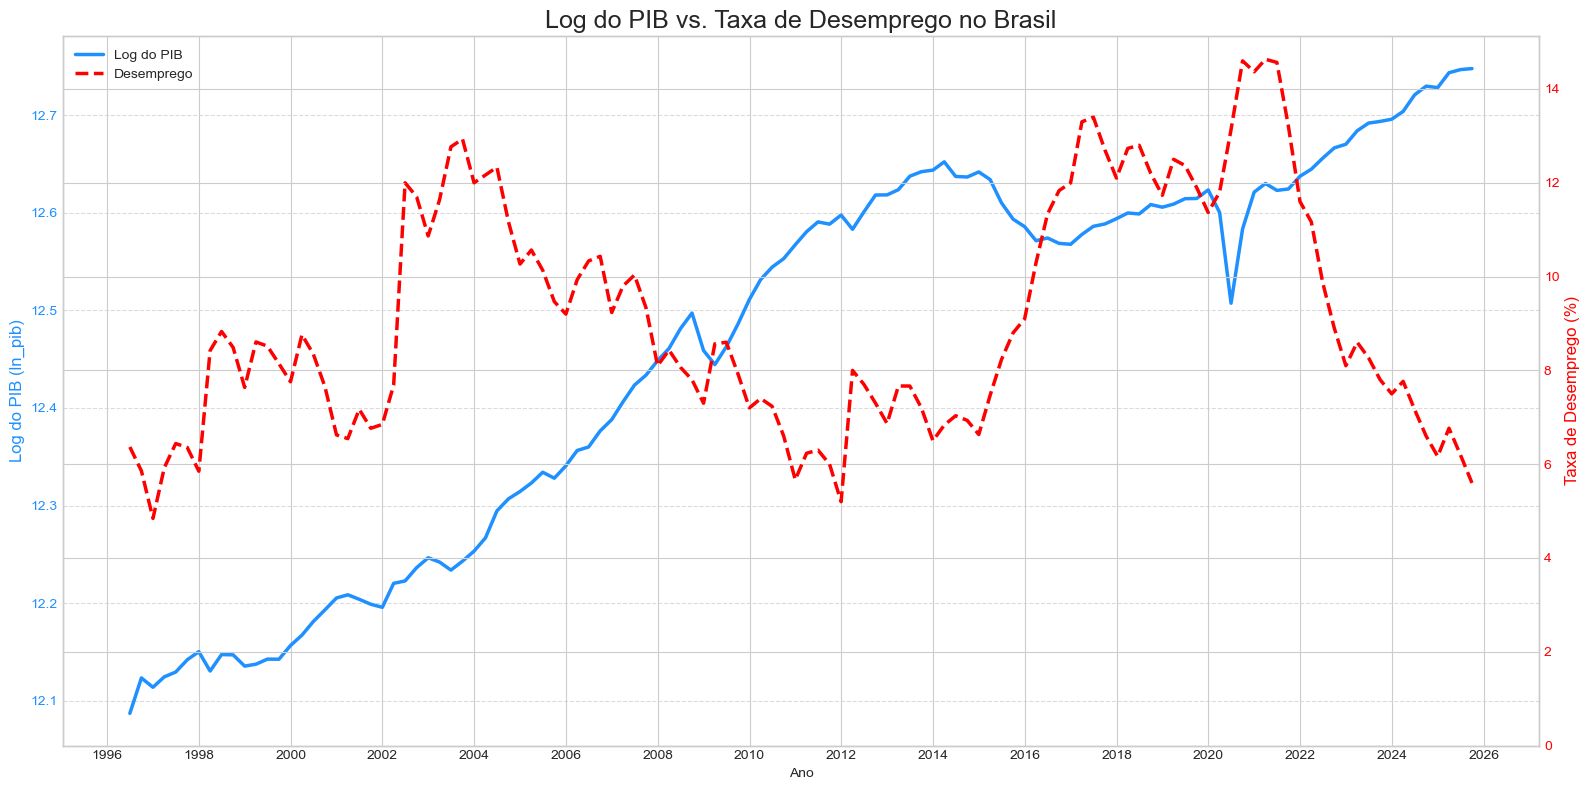

In [2]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Configurações de Estilo (Opcional) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

# --- Criação do Gráfico com Dois Eixos Y ---

fig, ax1 = plt.subplots()

# Título do Gráfico
ax1.set_title('Log do PIB vs. Taxa de Desemprego no Brasil', fontsize=18)

# --- Eixo 1 (Esquerda): Log do PIB ---
color1 = 'dodgerblue'
ax1.set_xlabel('Ano')
ax1.set_ylabel('Log do PIB (ln_pib)', color=color1, fontsize=12)
ax1.plot(df_final.index, df_final['ln_pib'], color=color1, linewidth=2.5, label='Log do PIB')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# --- Eixo 2 (Direita): Taxa de Desemprego ---
ax2 = ax1.twinx()  # Cria um segundo eixo que compartilha o mesmo eixo X
color2 = 'red'
ax2.set_ylabel('Taxa de Desemprego (%)', color=color2, fontsize=12)
ax2.plot(df_final.index, df_final['u_t'], color=color2, linewidth=2.5, linestyle='--', label='Desemprego')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(bottom=0) # Garante que a taxa de desemprego comece em 0


# --- Legenda Combinada ---
# Pega as linhas e os rótulos de ambos os eixos para criar uma única legenda
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')


# --- Formatação do Eixo X (Data) ---
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)


# --- Finalização ---
fig.tight_layout()  # Ajusta o layout para evitar sobreposição
plt.show()

In [3]:
# Célula para Testes de Estacionariedade (Raiz Unitária) - VERSÃO COM VALORES CRÍTICOS
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

# Ignorar avisos do teste KPSS para uma saída mais limpa
warnings.filterwarnings('ignore', category=UserWarning)

# --- CONFIGURAÇÃO ---
df_testes = df_final

variaveis_para_testar = {
    'u_t': 'Desemprego (u_t)',
    'ln_pib': 'Log do PIB (ln_pib_t)',
    'delta_u_t': 'Variação do Desemprego (Δu_t)',
    'crescimento_pib': 'Crescimento do PIB (crescimento_pib_t)'
}

# --- EXECUÇÃO DOS TESTES ---

print("="*60)
print("Executando Testes de Estacionariedade (com Valores Críticos)")
print("="*60)
print("Objetivo esperado:")
print("- Séries em NÍVEL (Desemprego, Log do PIB): NÃO ESTACIONÁRIAS (I(1))")
print("- Séries em DIFERENÇA (Variação Desemprego, Crescimento PIB): ESTACIONÁRIAS (I(0))\n")


for nome_coluna, nome_bonito in variaveis_para_testar.items():
    
    serie = df_testes[nome_coluna]
    
    print(f"\n--- Testando a variável: {nome_bonito} ---\n")
    
    # 1. Teste Augmented Dickey-Fuller (ADF)
    print("1. Teste ADF (Augmented Dickey-Fuller)")
    # H₀: A série TEM uma raiz unitária (não é estacionária).
    
    resultado_adf = adfuller(serie)
    estatistica_adf = resultado_adf[0]
    p_valor_adf = resultado_adf[1]
    valores_criticos_adf = resultado_adf[4]
    
    print(f"   - Estatística do Teste: {estatistica_adf:.4f}")
    print(f"   - P-valor: {p_valor_adf:.4f}")
    print("   - Valores Críticos (Estatística Limite):")
    for key, value in valores_criticos_adf.items():
        print(f'     - {key}: {value:.4f}')

    # A conclusão é baseada na estatística de teste ser MAIS NEGATIVA que os valores críticos.
    if p_valor_adf < 0.05:
        print("   - Conclusão: Rejeitamos H₀. A estatística de teste é menor que os valores críticos. A série é ESTACIONÁRIA.")
    else:
        print("   - Conclusão: Não rejeitamos H₀. A estatística de teste é maior que os valores críticos. A série é NÃO ESTACIONÁRIA.")
        
    print("-" * 25)

    # 2. Teste KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
    print("2. Teste KPSS")
    # H₀: A série É estacionária.
    
    resultado_kpss = kpss(serie, regression='ct', nlags="auto")
    estatistica_kpss = resultado_kpss[0]
    p_valor_kpss = resultado_kpss[1]
    valores_criticos_kpss = resultado_kpss[3]
    
    print(f"   - Estatística do Teste: {estatistica_kpss:.4f}")
    print(f"   - P-valor: {p_valor_kpss:.4f}")
    print("   - Valores Críticos (Estatística Limite):")
    for key, value in valores_criticos_kpss.items():
        print(f'     - {key}: {value:.4f}')
        
    # A conclusão é baseada na estatística de teste ser MENOR que os valores críticos.
    if p_valor_kpss < 0.05:
        print("   - Conclusão: Rejeitamos H₀. A estatística de teste é maior que os valores críticos. A série é NÃO ESTACIONÁRIA.")
    else:
        print("   - Conclusão: Não rejeitamos H₀. A estatística de teste é menor que os valores críticos. A série é ESTACIONÁRIA.")
        
    print("\n" + "="*50)

Executando Testes de Estacionariedade (com Valores Críticos)
Objetivo esperado:
- Séries em NÍVEL (Desemprego, Log do PIB): NÃO ESTACIONÁRIAS (I(1))
- Séries em DIFERENÇA (Variação Desemprego, Crescimento PIB): ESTACIONÁRIAS (I(0))


--- Testando a variável: Desemprego (u_t) ---

1. Teste ADF (Augmented Dickey-Fuller)
   - Estatística do Teste: -2.0510
   - P-valor: 0.2647
   - Valores Críticos (Estatística Limite):
     - 1%: -3.4907
     - 5%: -2.8880
     - 10%: -2.5809
   - Conclusão: Não rejeitamos H₀. A estatística de teste é maior que os valores críticos. A série é NÃO ESTACIONÁRIA.
-------------------------
2. Teste KPSS
   - Estatística do Teste: 0.1006
   - P-valor: 0.1000
   - Valores Críticos (Estatística Limite):
     - 10%: 0.1190
     - 5%: 0.1460
     - 2.5%: 0.1760
     - 1%: 0.2160
   - Conclusão: Não rejeitamos H₀. A estatística de teste é menor que os valores críticos. A série é ESTACIONÁRIA.


--- Testando a variável: Log do PIB (ln_pib_t) ---

1. Teste ADF (Augmen

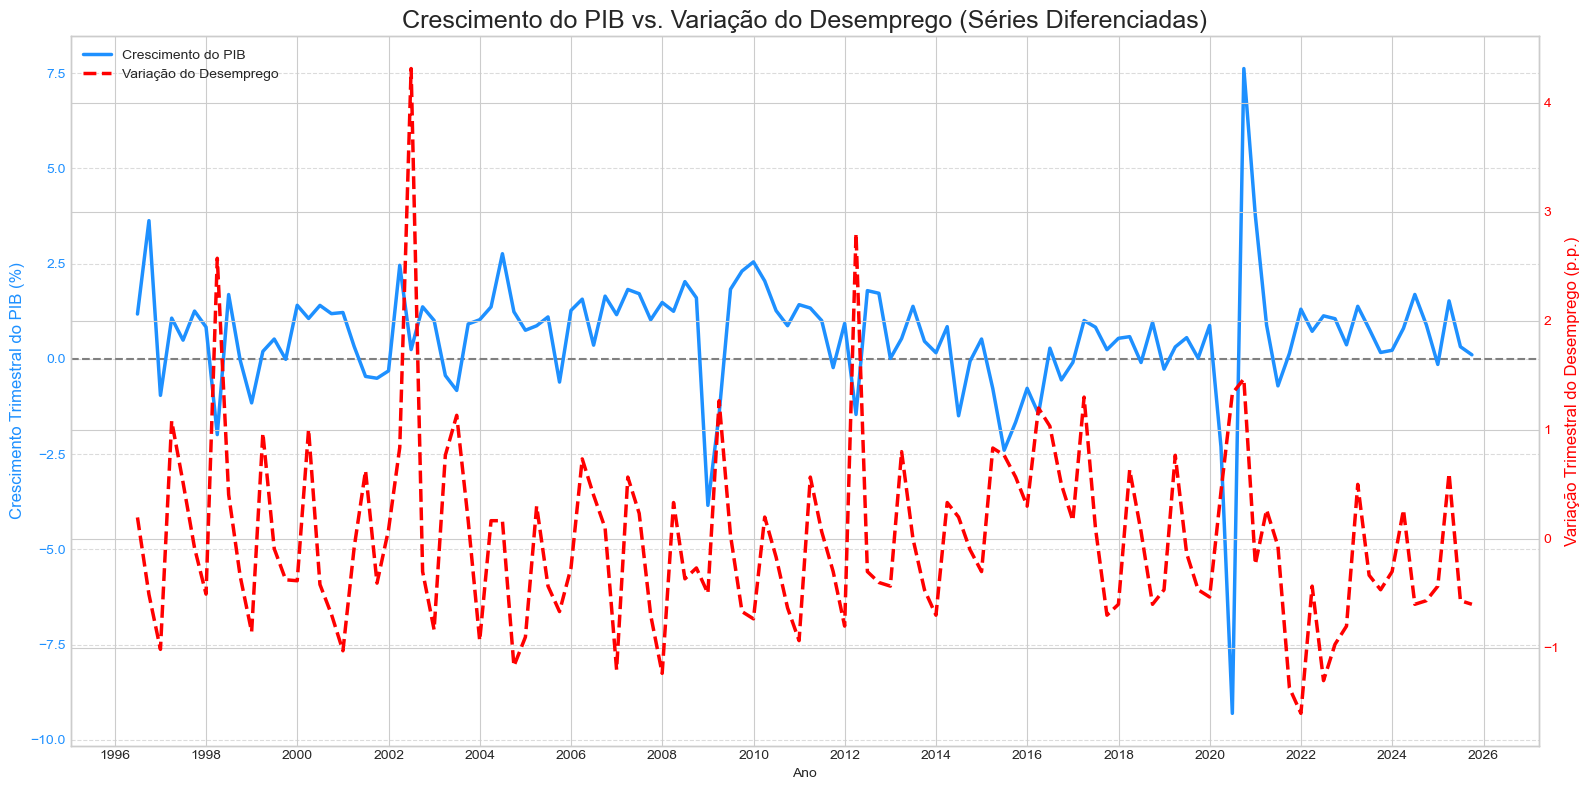

In [4]:
# Célula para o Gráfico das Séries em Primeira Diferença



# --- Configurações de Estilo (Opcional) ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 8)

# --- Criação do Gráfico com Dois Eixos Y ---

fig, ax1 = plt.subplots()

# Título do Gráfico
ax1.set_title('Crescimento do PIB vs. Variação do Desemprego (Séries Diferenciadas)', fontsize=18)

# Adiciona uma linha horizontal em y=0 para referência visual da média
ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1.5)

# --- Eixo 1 (Esquerda): Crescimento do PIB ---
color1 = 'dodgerblue'
ax1.set_xlabel('Ano')
ax1.set_ylabel('Crescimento Trimestral do PIB (%)', color=color1, fontsize=12)
ax1.plot(df_final.index, df_final['crescimento_pib'], color=color1, linewidth=2.5, label='Crescimento do PIB')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# --- Eixo 2 (Direita): Variação da Taxa de Desemprego ---
ax2 = ax1.twinx()  # Cria um segundo eixo que compartilha o mesmo eixo X
color2 = 'red'
ax2.set_ylabel('Variação Trimestral do Desemprego (p.p.)', color=color2, fontsize=12)
ax2.plot(df_final.index, df_final['delta_u_t'], color=color2, linewidth=2.5, linestyle='--', label='Variação do Desemprego')
ax2.tick_params(axis='y', labelcolor=color2)


# --- Legenda Combinada ---
# Pega as linhas e os rótulos de ambos os eixos para criar uma única legenda
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')


# --- Formatação do Eixo X (Data) ---
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)


# --- Finalização ---
fig.tight_layout()  # Ajusta o layout para evitar sobreposição
plt.show()

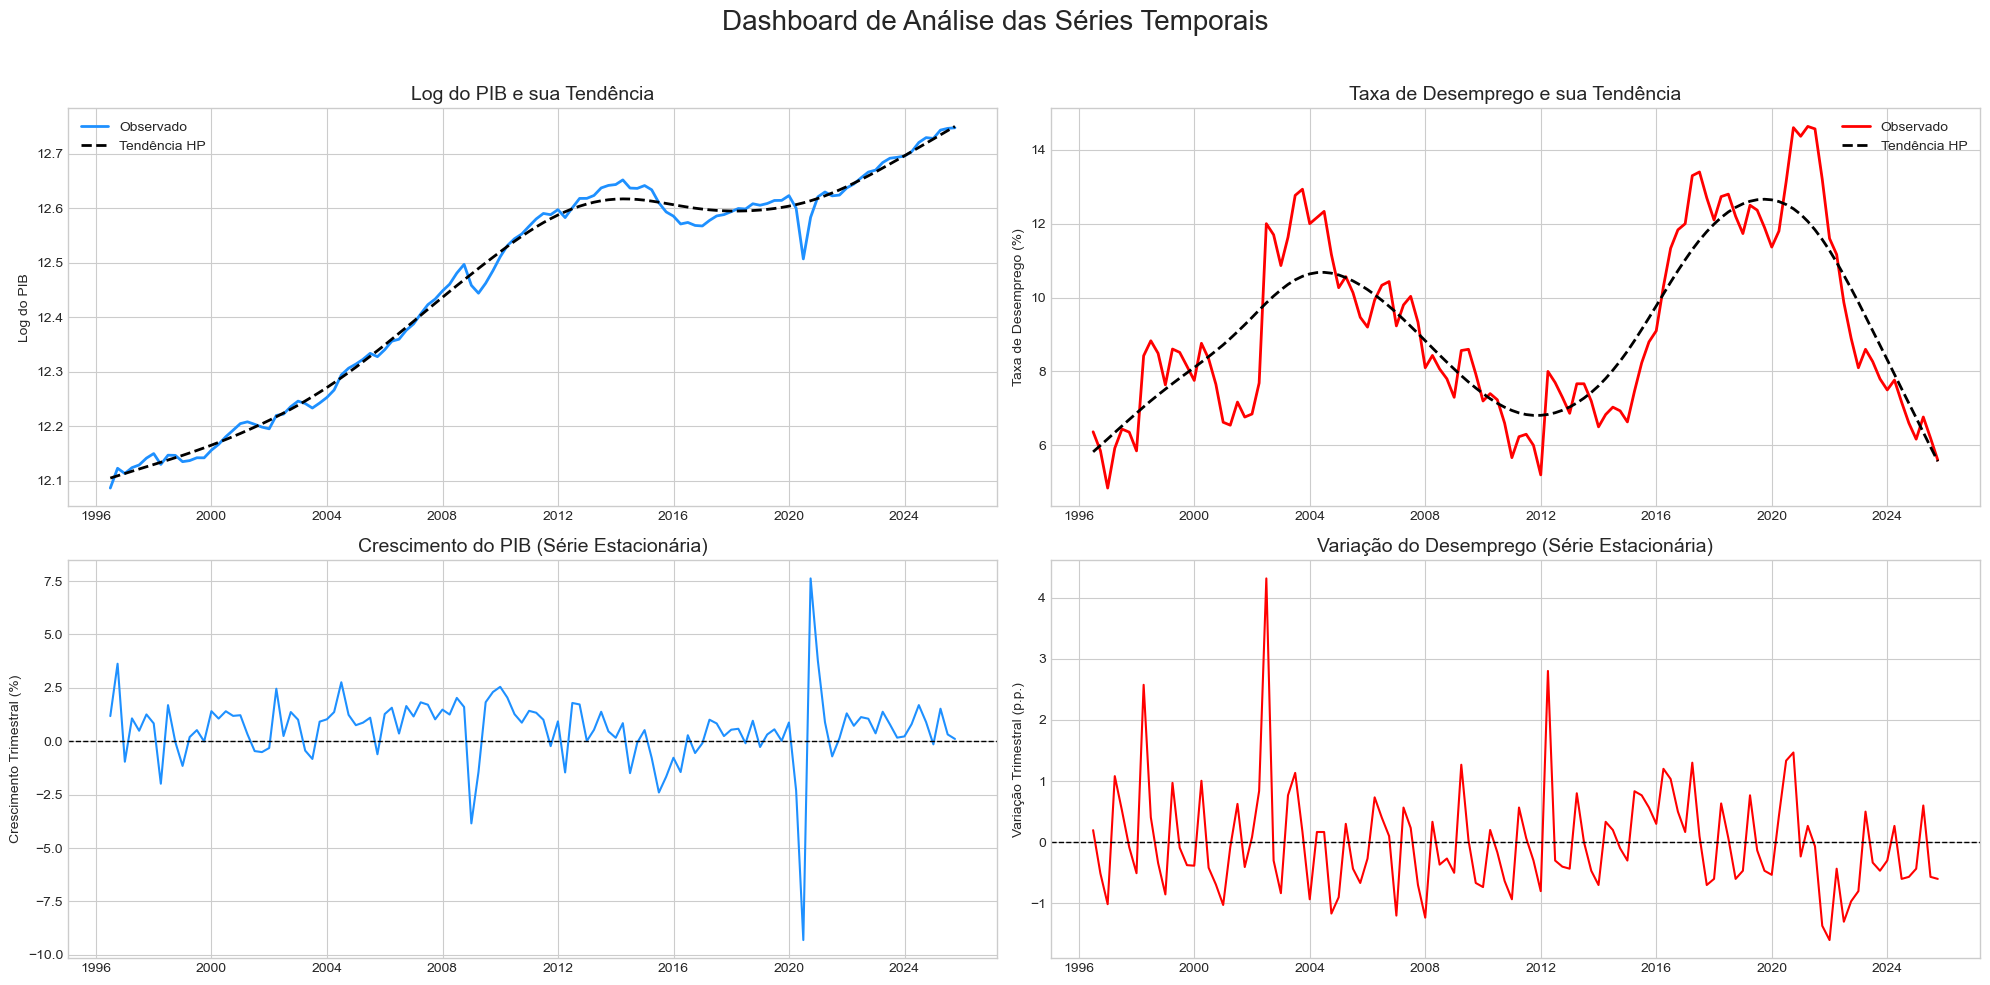

In [5]:
# Célula para o Dashboard de Análise Visual (Originais, Tendência e Diferenciadas)

from statsmodels.tsa.filters.hp_filter import hpfilter

# --- 1. PREPARAÇÃO: EXTRAIR TENDÊNCIA COM FILTRO HP ---

# O lambda=1600 é o valor padrão e recomendado para dados trimestrais.
pib_ciclo, pib_tendencia = hpfilter(df_final['ln_pib'], lamb=1600)
desemprego_ciclo, desemprego_tendencia = hpfilter(df_final['u_t'], lamb=1600)

# Adicionar as novas séries ao dataframe para facilitar o acesso
df_final['pib_tendencia_hp'] = pib_tendencia
df_final['desemprego_tendencia_hp'] = desemprego_tendencia


# --- 2. CRIAÇÃO DOS GRÁFICOS (GRID 2x2) ---

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(20, 10)) # 2 linhas, 2 colunas
fig.suptitle('Dashboard de Análise das Séries Temporais', fontsize=20)


# --- Gráfico 1 (Superior Esquerdo): PIB e Tendência ---
ax = axes[0, 0]
ax.plot(df_final.index, df_final['ln_pib'], label='Observado', color='dodgerblue', linewidth=2)
ax.plot(df_final.index, df_final['pib_tendencia_hp'], label='Tendência HP', color='black', linestyle='--', linewidth=2)
ax.set_title('Log do PIB e sua Tendência', fontsize=14)
ax.set_ylabel('Log do PIB')
ax.legend()
ax.grid(True)


# --- Gráfico 2 (Superior Direito): Desemprego e Tendência ---
ax = axes[0, 1]
ax.plot(df_final.index, df_final['u_t'], label='Observado', color='red', linewidth=2)
ax.plot(df_final.index, df_final['desemprego_tendencia_hp'], label='Tendência HP', color='black', linestyle='--', linewidth=2)
ax.set_title('Taxa de Desemprego e sua Tendência', fontsize=14)
ax.set_ylabel('Taxa de Desemprego (%)')
ax.legend()
ax.grid(True)


# --- Gráfico 3 (Inferior Esquerdo): Crescimento do PIB (Diferenciado) ---
ax = axes[1, 0]
ax.plot(df_final.index, df_final['crescimento_pib'], color='dodgerblue')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Crescimento do PIB (Série Estacionária)', fontsize=14)
ax.set_ylabel('Crescimento Trimestral (%)')
ax.grid(True)


# --- Gráfico 4 (Inferior Direito): Variação do Desemprego (Diferenciado) ---
ax = axes[1, 1]
ax.plot(df_final.index, df_final['delta_u_t'], color='red')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Variação do Desemprego (Série Estacionária)', fontsize=14)
ax.set_ylabel('Variação Trimestral (p.p.)')
ax.grid(True)


# --- Ajustes Finais ---
# Ajusta o formato da data em todos os eixos
for ax_row in axes:
    for ax in ax_row:
        ax.xaxis.set_major_locator(mdates.YearLocator(4)) # Marca a cada 4 anos
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Ajusta para o título principal caber
plt.show()

In [6]:
# Ignorar alguns avisos do kpss para uma saída mais limpa
warnings.filterwarnings('ignore', category=UserWarning)

# Carregar os datasets tratados
pib_df = pd.read_pickle('pib_tratado.pkl')
desemprego_df = pd.read_pickle('desemprego_tratado.pkl')

# Renomear a coluna de desemprego para 'u_t' para consistência, caso ainda não tenha sido feito
if 'desemprego' in desemprego_df.columns:
    desemprego_df.rename(columns={'desemprego': 'u_t'}, inplace=True)

# Unificar os dataframes, garantindo que ambos tenham dados para o período
df_completo = pib_df.join(desemprego_df, how='inner')

# --- 1. Ajuste do Período de Análise ---
# Filtrar o DataFrame para incluir dados somente até o final de 2024
df_filtrado = df_completo[df_completo.index <= '2024-12-31'].copy()

print("O DataFrame foi ajustado para o período de {} a {}.".format(
    df_filtrado.index.min().strftime('%Y-%m-%d'),
    df_filtrado.index.max().strftime('%Y-%m-%d')
))
print(f"Total de observações após o filtro: {len(df_filtrado)}\n")


# --- Recriar as variáveis de primeira diferença com o novo período ---
# CORREÇÃO: Usando a coluna 'u_t' que é o nome correto no DataFrame
df_filtrado['delta_u_t'] = df_filtrado['u_t'].diff()
# A coluna 'crescimento_pib' já existe no pib_tratado.pkl, mas vamos recriá-la
# para garantir que ela corresponda exatamente ao período filtrado.
df_filtrado['crescimento_pib'] = df_filtrado['ln_pib'].diff() * 100

# Remover valores NaN gerados pela diferenciação
df_final_ajustado = df_filtrado.dropna()

print(f"Total de observações após remover NaNs: {len(df_final_ajustado)}\n")
print("--- 2. Novos Testes de Estacionariedade (ADF e KPSS) ---")

# Dicionário para armazenar as séries a serem testadas
series_para_testar = {
    'ln_pib': df_final_ajustado['ln_pib'],
    'u_t': df_final_ajustado['u_t'], # CORREÇÃO AQUI
    'crescimento_pib': df_final_ajustado['crescimento_pib'],
    'delta_u_t': df_final_ajustado['delta_u_t']
}

# Função para executar e imprimir os resultados dos testes
def executar_testes_estacionariedade(nome_serie, serie):
    print(f"--- Resultados para a série: {nome_serie} ---")
    
    # Teste ADF
    adf_result = adfuller(serie)
    print(f'Teste ADF:')
    print(f'  - Estatística do Teste: {adf_result[0]:.4f}')
    print(f'  - p-valor: {adf_result[1]:.4f}')
    if adf_result[1] <= 0.05:
        print("  - Conclusão (ADF): Rejeita H₀. A série é estacionária.")
    else:
        print("  - Conclusão (ADF): Não rejeita H₀. A série é não-estacionária.")

    # Teste KPSS
    regressao_kpss = 'ct' if nome_serie in ['ln_pib', 'u_t'] else 'c'
    
    kpss_result = kpss(serie, regression=regressao_kpss, nlags="auto")
    print(f'\nTeste KPSS (regression="{regressao_kpss}"):')
    print(f'  - Estatística do Teste: {kpss_result[0]:.4f}')
    print(f'  - p-valor: {kpss_result[1]:.4f}')
    if kpss_result[1] <= 0.05:
        print("  - Conclusão (KPSS): Rejeita H₀. A série é não-estacionária.")
    else:
        print("  - Conclusão (KPSS): Não rejeita H₀. A série é estacionária.")
    print("-" * 40)

# Executar os testes para cada série
for nome, serie in series_para_testar.items():
    executar_testes_estacionariedade(nome, serie)

O DataFrame foi ajustado para o período de 1996-03-31 a 2024-12-31.
Total de observações após o filtro: 116

Total de observações após remover NaNs: 115

--- 2. Novos Testes de Estacionariedade (ADF e KPSS) ---
--- Resultados para a série: ln_pib ---
Teste ADF:
  - Estatística do Teste: -1.3073
  - p-valor: 0.6258
  - Conclusão (ADF): Não rejeita H₀. A série é não-estacionária.

Teste KPSS (regression="ct"):
  - Estatística do Teste: 0.3467
  - p-valor: 0.0100
  - Conclusão (KPSS): Rejeita H₀. A série é não-estacionária.
----------------------------------------
--- Resultados para a série: u_t ---
Teste ADF:
  - Estatística do Teste: -2.1186
  - p-valor: 0.2371
  - Conclusão (ADF): Não rejeita H₀. A série é não-estacionária.

Teste KPSS (regression="ct"):
  - Estatística do Teste: 0.1025
  - p-valor: 0.1000
  - Conclusão (KPSS): Não rejeita H₀. A série é estacionária.
----------------------------------------
--- Resultados para a série: crescimento_pib ---
Teste ADF:
  - Estatística do

In [7]:
# A variável 'df_final_ajustado' já deve existir da célula anterior.
# Vamos usar as duas colunas estacionárias para o teste.
from statsmodels.tsa.stattools import grangercausalitytests
data_para_teste = df_final_ajustado[['delta_u_t', 'crescimento_pib']].copy()

print("--- Teste de Causalidade de Granger ---")
print(f"Testando com até 4 trimestres de defasagem (lags).\n")
print("A Hipótese Nula (H₀) é que a série X NÃO causa (no sentido de Granger) a série Y.")
print("Um p-valor < 0.05 nos leva a rejeitar a H₀, indicando que há causalidade de Granger.\n")

# --- Teste 1: Crescimento do PIB -> Variação do Desemprego ---
# H₀: 'crescimento_pib' NÃO causa 'delta_u_t'
print("="*50)
print("Teste 1: O crescimento do PIB causa a variação do desemprego?")
print("H₀: crescimento_pib não causa delta_u_t")
print("="*50)
# A função espera que a primeira coluna seja a variável 'causada' (Y)
# e a segunda seja a variável 'causadora' (X).
resultado_1 = grangercausalitytests(data_para_teste[['delta_u_t', 'crescimento_pib']], maxlag=4, verbose=True)


# --- Teste 2: Variação do Desemprego -> Crescimento do PIB ---
# H₀: 'delta_u_t' NÃO causa 'crescimento_pib'
print("\n\n" + "="*50)
print("Teste 2: A variação do desemprego causa o crescimento do PIB?")
print("H₀: delta_u_t não causa crescimento_pib")
print("="*50)
resultado_2 = grangercausalitytests(data_para_teste[['crescimento_pib', 'delta_u_t']], maxlag=4, verbose=True)

--- Teste de Causalidade de Granger ---
Testando com até 4 trimestres de defasagem (lags).

A Hipótese Nula (H₀) é que a série X NÃO causa (no sentido de Granger) a série Y.
Um p-valor < 0.05 nos leva a rejeitar a H₀, indicando que há causalidade de Granger.

Teste 1: O crescimento do PIB causa a variação do desemprego?
H₀: crescimento_pib não causa delta_u_t

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.8811  , p=0.0099  , df_denom=111, df_num=1
ssr based chi2 test:   chi2=7.0670  , p=0.0079  , df=1
likelihood ratio test: chi2=6.8567  , p=0.0088  , df=1
parameter F test:         F=6.8811  , p=0.0099  , df_denom=111, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.6343  , p=0.0297  , df_denom=108, df_num=2
ssr based chi2 test:   chi2=7.6050  , p=0.0223  , df=2
likelihood ratio test: chi2=7.3600  , p=0.0252  , df=2
parameter F test:         F=3.6343  , p=0.0297  , df_denom=108, df_num=2

Granger Causality
number of lags 

c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\davyd\anaconda3\Lib\site-packages\statsmodels\tsa\stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
